In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

import numpy as np
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits
from tqdm import tqdm
import camb
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

import glass.shells
import glass.lensing
import glass.observations

from mass_mapping import kaiser_squire
from forward_model import preprocessing_gower_street, weight_map_w_redshift
from ray_trace import ray_trace_glass, ray_trace_bornraytrace

In [72]:
sim = 193

path_info = '/lustre/fsmisc/dataset/GowerStreetSims/PKDGRAV3_on_DiRAC_DES_330 - Sheet1.csv'
path_sims = '/lustre/fsmisc/dataset/GowerStreetSims/'

overdensity_array, z_bin_edges, cosmo_params = preprocessing_gower_street( path_sims, path_info, sim, nside=512, nside_intermediate=1024, verbose=True)

[!] Preprocessing the Gower Street simulation 193...
[!] Reading the cosmological parameters...


/lustre/fswork/projects/rech/prk/uid35yw/UNIONS_forward_model/utils.py:150: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(sigma8_difference, args=(cosmo_params, nside,), bounds=[np.log(1e-11), np.log(2e-8)], tol=1e-10)


[!] Done in 1.84 min.
[!] Extracting overdensity maps and redshift edges for the Gower Street simulation 193...


100it [09:29,  5.69s/it]


[!] Done in 9.50 min.
[!] Number of redshift shells: 99
[!] Larger redshift: 18.63619


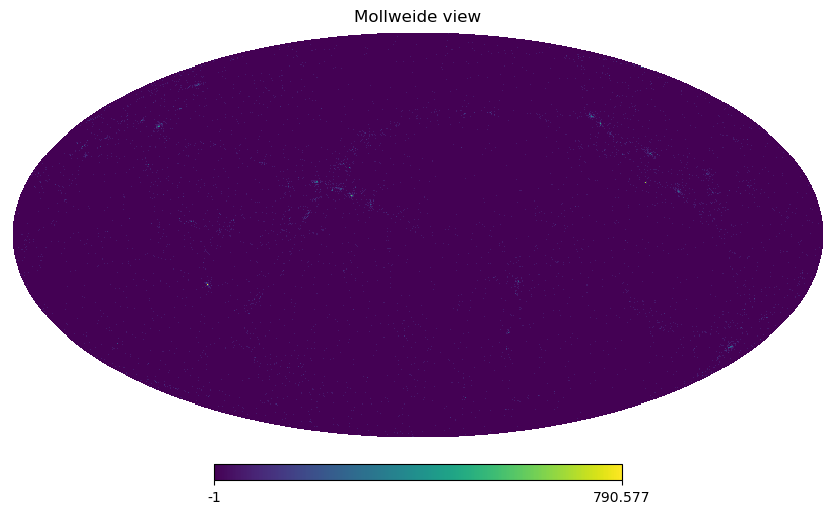

In [3]:
hp.mollview(overdensity_array[0])
plt.show()

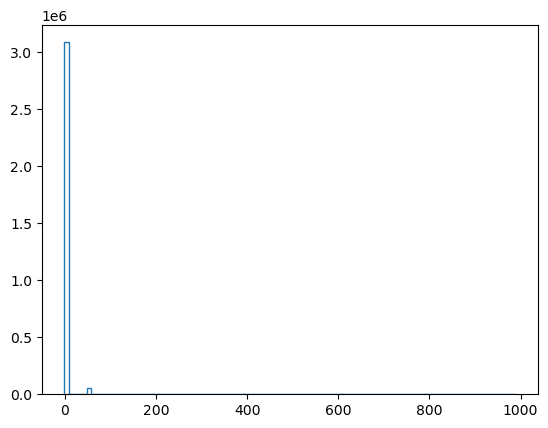

In [4]:
plt.figure()

plt.hist(overdensity_array[0], bins=100, histtype='step')

plt.show()

In [5]:
np.sum(overdensity_array[0] != -1)/len(overdensity_array[0])

0.018191973368326824

In [73]:
kappa_lensing_glass = ray_trace_glass(overdensity_array, z_bin_edges, cosmo_params, verbose=True)
kappa_lensing_brt = ray_trace_bornraytrace(overdensity_array, z_bin_edges, cosmo_params, verbose=True)

[!] Performing the ray tracing using GLASS...


100%|██████████| 99/99 [00:05<00:00, 19.79it/s]


[!] Performing the ray tracing using BornRaytrace...


100%|██████████| 99/99 [01:07<00:00,  1.46it/s]


In [7]:
hp.mollview(kappa_lensing[1])
plt.show()

NameError: name 'kappa_lensing' is not defined

In [ ]:
plt.figure()

plt.hist(kappa_lensing[50], bins=100, histtype='step')

plt.show()

In [79]:
n_shell = 60
nside = 512
lmax = 2*nside

cls_glass = hp.anafast(kappa_lensing_glass[n_shell], pol=True, lmax=lmax, use_pixel_weights=True)
cls_brt = hp.anafast(kappa_lensing_brt[n_shell], pol=True, lmax=lmax, use_pixel_weights=True)

#Checking the power spectrum of the convergence and shear fields
#Load parameters for the cosmology
h = cosmo_params["h"]
Om = cosmo_params["Omega_m"]
Ob = cosmo_params["Omega_b"]
Oc = Om - Ob
ns = cosmo_params["n_s"]
m_nu = cosmo_params["m_nu"]
w = cosmo_params["w"]
As = cosmo_params["A_s"]

pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, mnu=m_nu, w=w, As=As, WantTransfer=True, NonLinear=camb.model.NonLinear_both)
Onu = pars.omeganu
Oc = Om - Ob - Onu
pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, mnu=m_nu, w=w, As=As, WantTransfer=True, NonLinear=camb.model.NonLinear_both)

pars.min_l = 1
pars.set_for_lmax(lmax)
z_eff = 0.5*(z_bin_edges[n_shell] + z_bin_edges[n_shell+1])
pars.SourceWindows = [
    camb.sources.GaussianSourceWindow(redshift=z_eff, source_type='lensing', sigma=0.0002),
]

theory_cells = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)

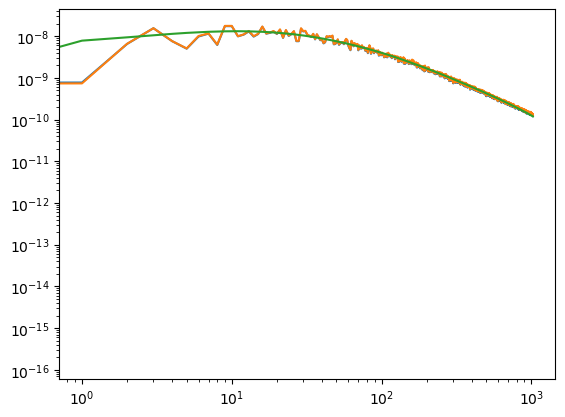

/tmp/ipykernel_1096797/895621627.py:18: RuntimeWarning: divide by zero encountered in divide
  plt.plot(ell, cls_glass/(theory_cells["W1xW1"] * pw **2))
/tmp/ipykernel_1096797/895621627.py:19: RuntimeWarning: divide by zero encountered in divide
  plt.plot(ell, cls_brt/(theory_cells["W1xW1"] * pw **2), alpha=0.5)


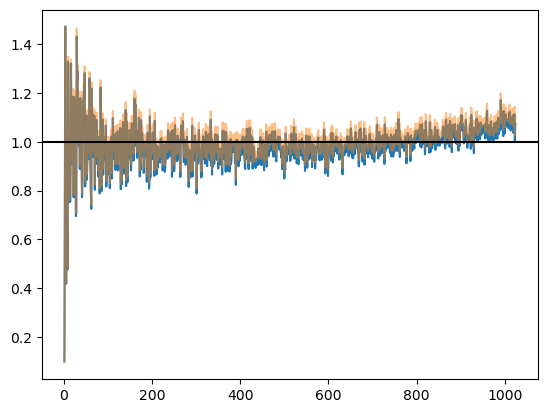

In [80]:
pw = hp.pixwin(nside, lmax=lmax)

plt.figure()

ell = np.arange(lmax+1)
plt.plot(ell, cls_glass)
plt.plot(ell, cls_brt)
plt.plot(ell, theory_cells["W1xW1"] * pw**2)


plt.xscale('log')
plt.yscale('log')

plt.show()

plt.figure()

plt.plot(ell, cls_glass/(theory_cells["W1xW1"] * pw **2))
plt.plot(ell, cls_brt/(theory_cells["W1xW1"] * pw **2), alpha=0.5)
plt.axhline(1, color='k')

plt.show()

In [67]:
redshift_distribution = np.loadtxt('../data_utils/nz_shapepipe_v1.4.5.txt')
z, nz = redshift_distribution[:, 0], redshift_distribution[:, 1]

In [46]:
z = np.arange(0.0, 5.0, 0.01)
nz = glass.observations.smail_nz(z, 0.5, 2.0, 5.0)

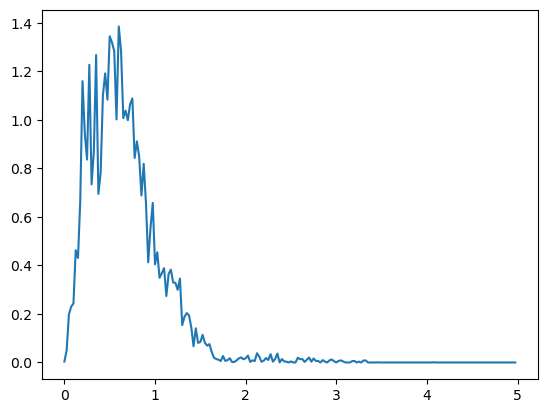

In [68]:

plt.plot(z, nz)

In [76]:
kappa_weighted_glass = weight_map_w_redshift(kappa_lensing_glass, z_bin_edges, (nz, z), verbose=True)[0]
kappa_weighted_brt = weight_map_w_redshift(kappa_lensing_brt, z_bin_edges, (nz, z), verbose=True)[0]


100%|██████████| 99/99 [00:01<00:00, 73.51it/s]


In [81]:

nside = 512
lmax = 2*nside

cls_glass = hp.anafast(kappa_weighted_glass, pol=True, lmax=lmax, use_pixel_weights=True)
cls_brt = hp.anafast(kappa_weighted_brt, pol=True, lmax=lmax, use_pixel_weights=True)

#Checking the power spectrum of the convergence and shear fields
#Load parameters for the cosmology
h = cosmo_params["h"]
Om = cosmo_params["Omega_m"]
Ob = cosmo_params["Omega_b"]
Oc = Om - Ob
ns = cosmo_params["n_s"]
m_nu = cosmo_params["m_nu"]
w = cosmo_params["w"]
As = cosmo_params["A_s"]

pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, mnu=m_nu, w=w, As=As, WantTransfer=True, NonLinear=camb.model.NonLinear_both, halofit_version="takahashi")
Onu = pars.omeganu
Oc = Om - Ob - Onu
pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, mnu=m_nu, w=w, As=As, WantTransfer=True, NonLinear=camb.model.NonLinear_both, halofit_version="takahashi")

pars.min_l = 1
pars.set_for_lmax(lmax)
z_eff = 0.5*(z_bin_edges[n_shell] + z_bin_edges[n_shell+1])
pars.SourceWindows = [
    camb.sources.SplinedSourceWindow(z=z, W=nz, source_type='lensing')
]


theory_cells = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)

In [ ]:
pw = hp.pixwin(nside, lmax=lmax)

plt.figure()

ell = np.arange(lmax+1)
plt.plot(ell, cls_glass)
plt.plot(ell, cls_brt)
plt.plot(ell, theory_cells["W1xW1"] * pw**2)

plt.xscale('log')
plt.yscale('log')

plt.show()

plt.figure()

plt.plot(ell, cls_glass/(theory_cells["W1xW1"] * pw **2))
plt.plot(ell, cls_brt/(theory_cells["W1xW1"]*pw**2))
plt.axhline(1, color='k')
plt.axhline(1.02, color='grey')
plt.axhline(0.98, color='grey')
plt.axhline(1.10, color='grey')

plt.show()

In [15]:
alms_glass = hp.map2alm(kappa_weighted_glass, lmax=lmax)

In [20]:
l_cut = 800
for l in tqdm(range(len(alms_glass))):
    ell, m = hp.Alm.getlm(lmax, l)
    if ell > l_cut:
        alms_glass[l] = 0.0

100%|██████████| 525825/525825 [00:09<00:00, 58154.84it/s]


In [22]:
kappa_weighted_cut = hp.alm2map(alms_glass, nside=512)
cls_cut = hp.anafast(kappa_weighted_cut, pol=True, lmax=lmax, use_pixel_weights=True)

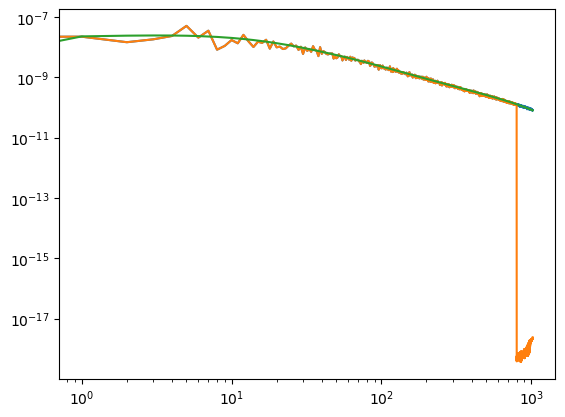

/tmp/ipykernel_1096797/1961246645.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.plot(ell, cls_glass/(theory_cells["W1xW1"] * pw **2))
/tmp/ipykernel_1096797/1961246645.py:18: RuntimeWarning: divide by zero encountered in divide
  plt.plot(ell, cls_cut/(theory_cells["W1xW1"]*pw**2))


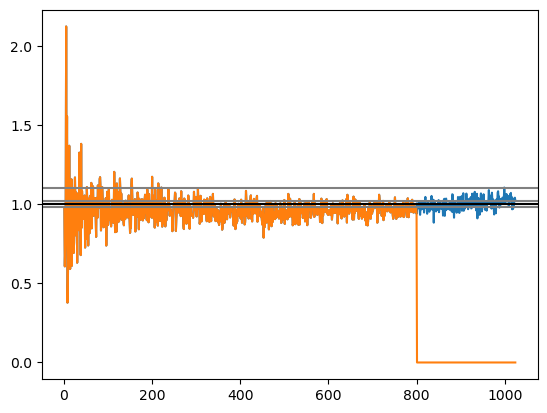

In [23]:
pw = hp.pixwin(nside, lmax=lmax)

plt.figure()

ell = np.arange(lmax+1)
plt.plot(ell, cls_glass)
plt.plot(ell, cls_cut)
plt.plot(ell, theory_cells["W1xW1"] * pw**2)

plt.xscale('log')
plt.yscale('log')

plt.show()

plt.figure()

plt.plot(ell, cls_glass/(theory_cells["W1xW1"] * pw **2))
plt.plot(ell, cls_cut/(theory_cells["W1xW1"]*pw**2))
plt.axhline(1, color='k')
plt.axhline(1.02, color='grey')
plt.axhline(0.98, color='grey')
plt.axhline(1.10, color='grey')

plt.show()

In [108]:
tophat_weights = glass.shells.tophat_windows(z_bin_edges)
linear_weights = glass.shells.linear_windows(z_bin_edges)

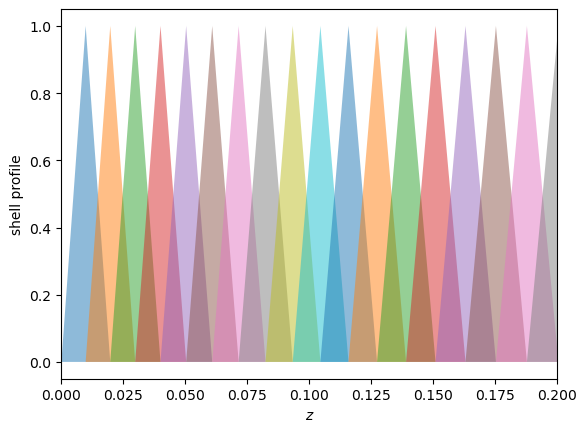

In [11]:
# show the linear windows
for shell in linear_weights:
    plt.fill(shell.za, shell.wa, alpha=0.5)
plt.xlabel("$z$")
plt.ylabel("shell profile")
plt.xlim(0.0, 0.2)
plt.show()

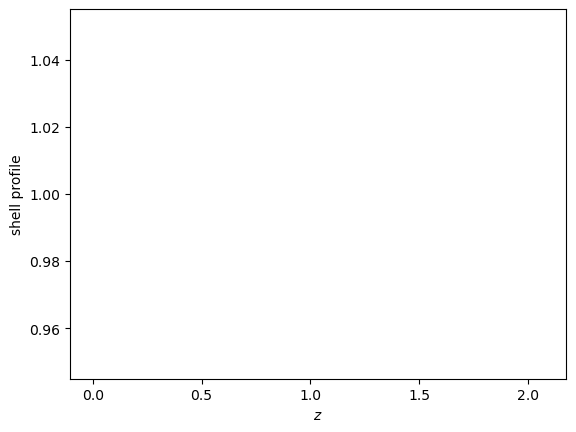

In [12]:
# show the linear windows
for shell in tophat_weights:
    plt.fill(shell.za, shell.wa, alpha=0.5)
plt.xlabel("$z$")
plt.ylabel("shell profile")
plt.show()

In [13]:
linear_weights[0]

RadialWindow(za=array([0.        , 0.00108656, 0.00217311, 0.00325967, 0.00434622,
       0.00543278, 0.00651933, 0.00760589, 0.00869244, 0.009779  ,
       0.01088078, 0.01198256, 0.01308433, 0.01418611, 0.01528789,
       0.01638967, 0.01749144, 0.01859322, 0.019695  ]), wa=array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ,
       0.88888889, 0.77777778, 0.66666667, 0.55555556, 0.44444444,
       0.33333333, 0.22222222, 0.11111111, 0.        ]), zeff=0.009779)

In [14]:
z_bin_edges

array([0.      , 0.009779, 0.019695, 0.029753, 0.039956, 0.050307,
       0.060811, 0.071471, 0.082292, 0.093278, 0.104434, 0.115765,
       0.127275, 0.138969, 0.150854, 0.162935, 0.175217, 0.187706,
       0.20041 , 0.213335, 0.226488, 0.239876, 0.253507, 0.26739 ,
       0.281532, 0.295942, 0.310631, 0.325607, 0.340881, 0.356465,
       0.372368, 0.388604, 0.405186, 0.422126, 0.439439, 0.457139,
       0.475244, 0.493768, 0.512731, 0.532151, 0.552048, 0.572443,
       0.593358, 0.614819, 0.63685 , 0.659479, 0.682734, 0.706648,
       0.731253, 0.756585, 0.782682, 0.809587, 0.837343, 0.865997,
       0.895603, 0.926214, 0.957892, 0.990703, 1.02472 , 1.06001 ,
       1.09667 , 1.13479 , 1.17447 , 1.21582 , 1.25896 , 1.30403 ,
       1.35117 , 1.40056 , 1.45238 , 1.50683 , 1.56414 , 1.62458 ,
       1.68843 , 1.75603 , 1.82776 , 1.90405 , 1.9854  , 2.07237 ])

In [21]:
z = np.arange(0.0, 5.0, 0.01)
nz = glass.observations.smail_nz(z, 1.0, 1.5, 2.0)

In [91]:
redshift_distribution = np.loadtxt('../data_utils/nz_shapepipe_v1.4.5.txt')
z, nz = redshift_distribution[:, 0], redshift_distribution[:, 1]

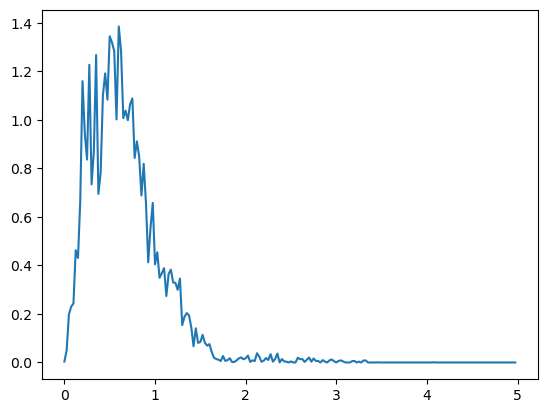

In [93]:
plt.plot(z, nz)

In [94]:
nz_grid = np.interp(z_bin_edges, z, nz)

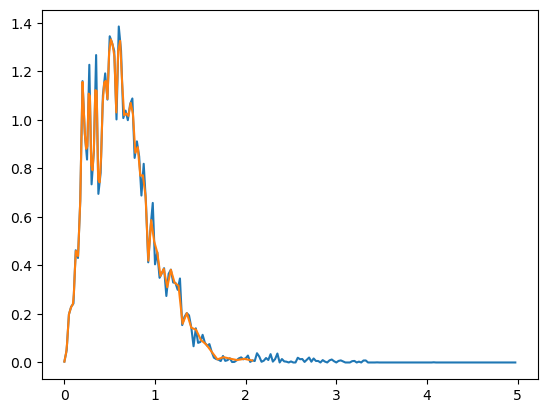

In [95]:
plt.plot(z, nz)
plt.plot(z_bin_edges, nz_grid)

In [102]:
ngal = glass.shells.partition(z, nz, linear_weights)

In [103]:
ngal

array([0.00023349, 0.00037462, 0.00076724, 0.00143779, 0.00207697,
       0.00224176, 0.00242505, 0.00257124, 0.00258954, 0.0030837 ,
       0.00442234, 0.0054161 , 0.00520975, 0.00522351, 0.00673617,
       0.0082748 , 0.01157462, 0.01489605, 0.01359222, 0.01246532,
       0.0117807 , 0.01187083, 0.01609346, 0.01631663, 0.01130653,
       0.01157113, 0.01316397, 0.01791556, 0.01846712, 0.01157853,
       0.01192841, 0.01402729, 0.01840874, 0.02042599, 0.02098725,
       0.01972805, 0.02435193, 0.02579148, 0.02571418, 0.02576786,
       0.02055564, 0.02759057, 0.02975882, 0.02542922, 0.02296969,
       0.0243766 , 0.02434115, 0.02731668, 0.02635107, 0.02222343,
       0.02526686, 0.0208523 , 0.02255236, 0.0215483 , 0.01237628,
       0.02060327, 0.01681235, 0.01445065, 0.01271346, 0.01413888,
       0.01165303, 0.01592713, 0.01305754, 0.01513816, 0.00788653,
       0.01040499, 0.00654044, 0.00532067, 0.00528361, 0.00499467,
       0.0028266 , 0.00037464, 0.00121021, 0.00053384, 0.00064

In [104]:
nz_eff = np.sum(  # type: ignore[no-any-return]
        [
            np.expand_dims(weight, -1)
            * np.interp(
                z,
                shell.za,
                shell.wa / np.trapz(shell.wa, shell.za),
                left=0.0,
                right=0.0,
            )
            for shell, weight in zip(linear_weights, ngal, strict=False)
        ],
        axis=0,
    )

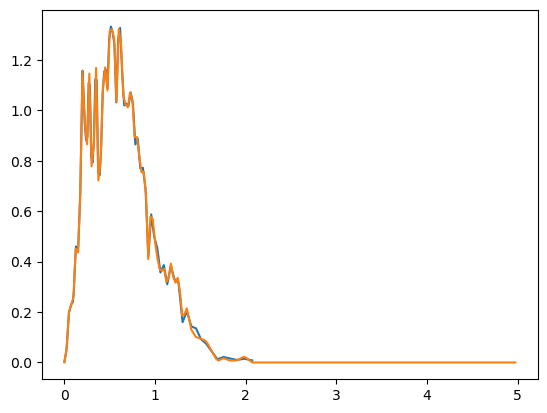

In [105]:
plt.plot(z_bin_edges, nz_grid)
plt.plot(z, nz_eff)

In [48]:
ngal

array([5.94900165e-06, 2.74676331e-05, 5.95394730e-05, 1.01210382e-04,
       1.57934549e-04, 1.99630565e-04, 2.55577801e-04, 3.25281197e-04,
       4.03594024e-04, 4.88941089e-04, 5.84932150e-04, 6.88959964e-04,
       8.02995124e-04, 9.35549435e-04, 1.05548969e-03, 1.19218957e-03,
       1.34578886e-03, 1.57095063e-03, 1.70715348e-03, 1.86709667e-03,
       2.11371861e-03, 2.39936686e-03, 2.52752906e-03, 2.75072980e-03,
       3.03129549e-03, 3.37895794e-03, 3.62847654e-03, 3.94741281e-03,
       4.27077640e-03, 4.57481697e-03, 4.98284844e-03, 5.34854144e-03,
       5.74838179e-03, 6.26977769e-03, 6.80395859e-03, 7.13949451e-03,
       7.64425484e-03, 8.18001619e-03, 8.74486249e-03, 9.32233251e-03,
       9.94506909e-03, 1.05820106e-02, 1.12641311e-02, 1.19579858e-02,
       1.28029824e-02, 1.36905871e-02, 1.42371446e-02, 1.50230512e-02,
       1.58944249e-02, 1.66992518e-02, 1.77620739e-02, 1.88576670e-02,
       1.94081267e-02, 2.03472897e-02, 2.12764703e-02, 2.21868661e-02,
      